In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import time
from collections import defaultdict

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  No GPU found. Training will be slower. Consider Runtime > Change runtime type > T4 GPU")


Using device: cuda
GPU: Tesla T4


In [ ]:
# ── Data ──────────────────────────────────
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True,  num_workers=2)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=128, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:35<00:00, 4.82MB/s]


Lets build the same architecture we used in Lab4.

In [ ]:
# MLP Model
class MLP(nn.Module):
    def __init__(self, input_dim=3072, hidden_sizes=[256, 128], num_classes=10, dropout=0.1):
        super().__init__()
        layers = []
        prev_size = input_dim
        for h in hidden_sizes:
            layers += [
                nn.Linear(prev_size, h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev_size = h
        layers.append(nn.Linear(prev_size, num_classes))

        self.network = nn.Sequential(nn.Flatten(), *layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.network(x)


model = MLP().to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nMLP architecture : 3072 → 256 → 128 → 10")
print(f"Total parameters : {total_params:,}")


MLP architecture : 3072 → 256 → 128 → 10
Total parameters : 820,874


In [ ]:
# Train MLP with same hyperparameters: Relu, Adam, Cosine Annealing, Weight Decay, Dropout
NUM_EPOCHS = 20

optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
criterion = nn.CrossEntropyLoss()

history = {'train_loss': [], 'test_acc': [], 'lr': []}


print("Training MLP on CIFAR-10")

for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    # Train
    model.train()
    total_loss = 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(inputs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Evaluate
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            preds = model(inputs).argmax(dim=1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)

    avg_loss = total_loss / len(trainloader)
    acc      = 100. * correct / total

    scheduler.step()
    lr_now = scheduler.get_last_lr()[0]

    history['train_loss'].append(avg_loss)
    history['test_acc'].append(acc)
    history['lr'].append(lr_now)

    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  "
          f"Loss: {avg_loss:.4f}  "
          f"Test Acc: {acc:.1f}%  "
          f"LR: {lr_now:.5f}  "
          f"({time.time()-t0:.1f}s)")

print(f"\n✓ Best Test Accuracy: {max(history['test_acc']):.1f}%")

Training MLP on CIFAR-10
Epoch [ 1/20]  Loss: 1.7701  Test Acc: 45.1%  LR: 0.00099  (18.4s)
Epoch [ 2/20]  Loss: 1.5582  Test Acc: 46.9%  LR: 0.00098  (16.7s)
Epoch [ 3/20]  Loss: 1.4630  Test Acc: 50.1%  LR: 0.00095  (16.6s)
Epoch [ 4/20]  Loss: 1.3899  Test Acc: 51.0%  LR: 0.00090  (15.6s)
Epoch [ 5/20]  Loss: 1.3335  Test Acc: 51.5%  LR: 0.00085  (13.7s)
Epoch [ 6/20]  Loss: 1.2821  Test Acc: 52.9%  LR: 0.00079  (13.7s)
Epoch [ 7/20]  Loss: 1.2379  Test Acc: 52.7%  LR: 0.00073  (14.4s)
Epoch [ 8/20]  Loss: 1.1864  Test Acc: 53.6%  LR: 0.00065  (15.1s)
Epoch [ 9/20]  Loss: 1.1447  Test Acc: 54.1%  LR: 0.00058  (14.4s)
Epoch [10/20]  Loss: 1.0977  Test Acc: 54.8%  LR: 0.00050  (16.8s)
Epoch [11/20]  Loss: 1.0547  Test Acc: 55.0%  LR: 0.00042  (15.9s)
Epoch [12/20]  Loss: 1.0104  Test Acc: 55.5%  LR: 0.00035  (18.3s)
Epoch [13/20]  Loss: 0.9684  Test Acc: 55.8%  LR: 0.00027  (15.2s)
Epoch [14/20]  Loss: 0.9264  Test Acc: 56.0%  LR: 0.00021  (13.8s)
Epoch [15/20]  Loss: 0.8932  Test Acc

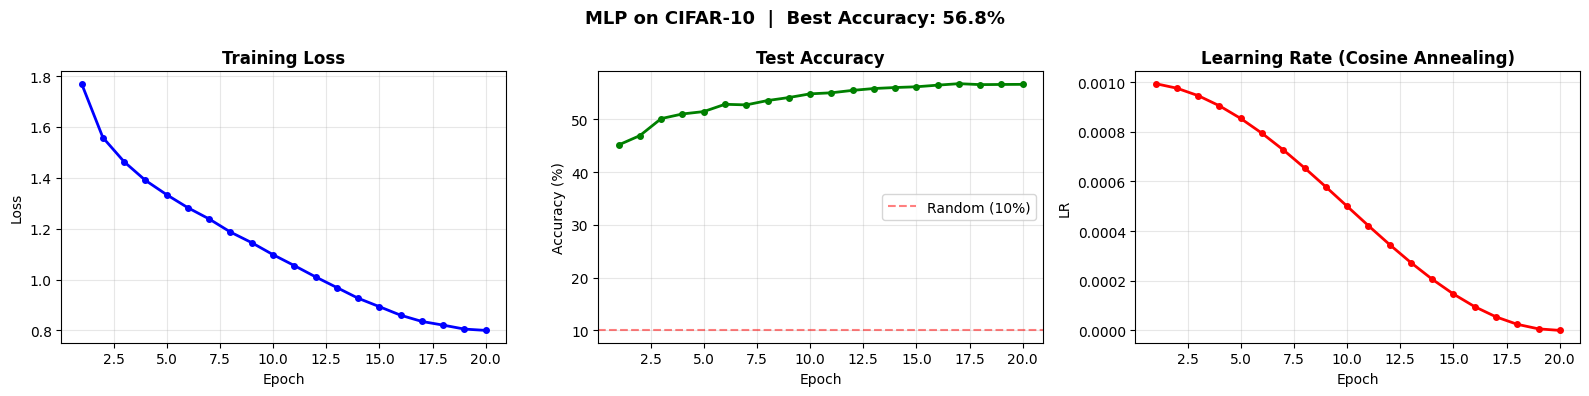

In [ ]:
# Plot MLP Training Result
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs, history['train_loss'], 'b-o', linewidth=2, markersize=4)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history['test_acc'], 'g-o', linewidth=2, markersize=4)
axes[1].axhline(y=10, color='red', linestyle='--', alpha=0.5, label='Random (10%)')
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, history['lr'], 'r-o', linewidth=2, markersize=4)
axes[2].set_title('Learning Rate (Cosine Annealing)', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('LR')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'MLP on CIFAR-10  |  Best Accuracy: {max(history["test_acc"]):.1f}%',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('mlp_training.png', dpi=150, bbox_inches='tight')
plt.show()

Why MLPs is not the best practice for Image Classification ?

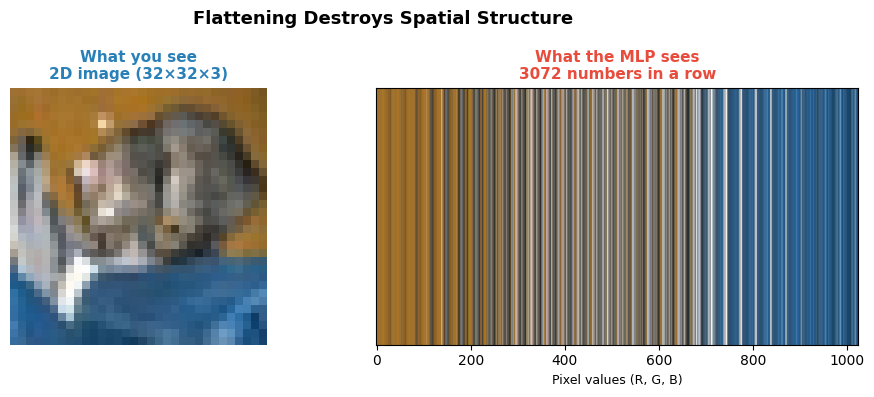

In [ ]:
# REASON 1: Flattening destroys spatial structure
# The MLP has NO idea which pixels are neighbors
transform_raw  = transforms.ToTensor()
transform_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
dataset_raw  = torchvision.datasets.CIFAR10('./data', train=False, download=False, transform=transform_raw)
dataset_norm = torchvision.datasets.CIFAR10('./data', train=False, download=False, transform=transform_norm)
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def get_sample(dataset, label_idx):
    for img, label in dataset:
        if label == label_idx:
            return img

label_indices = [3, 5, 1, 6]   # cat, dog, car, frog
true_names    = ['Cat', 'Dog', 'Car', 'Frog']
raws  = [get_sample(dataset_raw,  i) for i in label_indices]
norms = [get_sample(dataset_norm, i) for i in label_indices]
cat_raw = get_sample(dataset_raw, 3)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # Changed to 1x2, reduced figsize
fig.suptitle('Flattening Destroys Spatial Structure', fontsize=13, fontweight='bold')

# Original 2D image
axes[0].imshow(cat_raw.permute(1, 2, 0).clip(0, 1).numpy())
axes[0].set_title('What you see\n2D image (32×32×3)', fontweight='bold', fontsize=11, color='#2980b9')
axes[0].axis('off')

# Flattened: show as a 1D strip
flat = cat_raw.reshape(3, -1).permute(1, 0)   # (3072, 3)
axes[1].imshow(flat.unsqueeze(0).numpy(), aspect='auto')
axes[1].set_title('What the MLP sees\n3072 numbers in a row', fontweight='bold', fontsize=11, color='#e74c3c')
axes[1].set_xlabel('Pixel values (R, G, B)', fontsize=9)
axes[1].set_yticks([])

plt.tight_layout()

plt.savefig('mlp_flattening.png', dpi=150, bbox_inches='tight')
plt.show()

CIFAR-10 (32×32)          →         820,874 parameters
Instagram (256×256)       →      50,366,090 parameters
HD Photo (720p)           →     707,823,242 parameters
4K Photo (2160p)          →   6,370,133,642 parameters


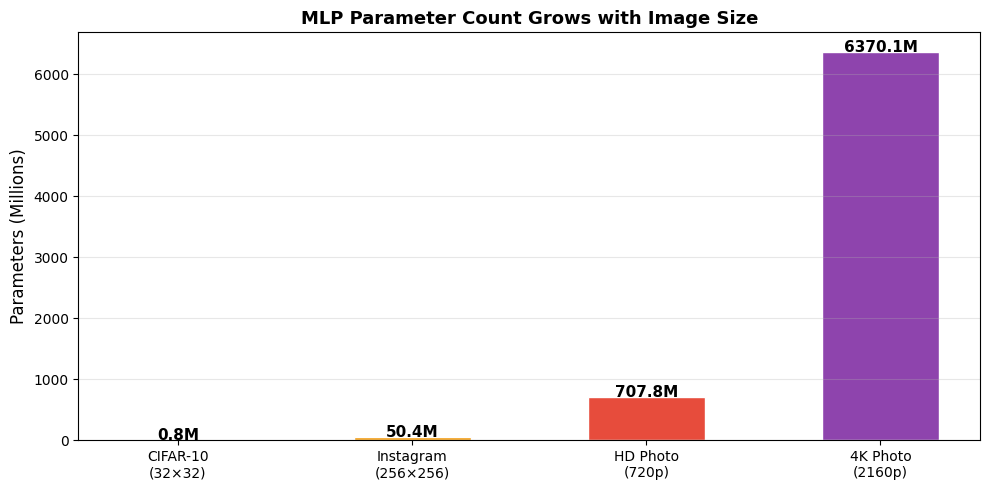

In [ ]:
# REASON 2: They explode with input size

image_sizes = [
    ("CIFAR-10\n(32×32)",    (32,  32,  3)),
    ("Instagram\n(256×256)", (256, 256, 3)),
    ("HD Photo\n(720p)",     (1280, 720, 3)),
    ("4K Photo\n(2160p)",    (3840, 2160, 3)),
]

def count_mlp_parameters(image_size, hidden_sizes, num_classes=10):
    """Count parameters for an MLP on an image."""
    input_dim = image_size[0] * image_size[1] * image_size[2]
    layers = [input_dim] + hidden_sizes + [num_classes]
    total = 0
    for i in range(len(layers) - 1):
        params = layers[i] * layers[i+1] + layers[i+1]  # weights + biases
        total += params
    return total, input_dim

param_counts = []
for label, size in image_sizes:
    params, _ = count_mlp_parameters(size, [256, 128])
    param_counts.append(params)
    print(f"{label.replace(chr(10), ' '):<25} → {params:>15,} parameters")

fig, ax = plt.subplots(figsize=(10, 5))
labels  = [s[0] for s in image_sizes]
colors  = ['#27AE60', '#F39C12', '#E74C3C', '#8E44AD']
bars    = ax.bar(labels, [p / 1e6 for p in param_counts], color=colors, edgecolor='white', width=0.5)

for bar, p in zip(bars, param_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{p/1e6:.1f}M', ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel('Parameters (Millions)', fontsize=12)
ax.set_title('MLP Parameter Count Grows with Image Size',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('param_explosion.png', dpi=150, bbox_inches='tight')
plt.show()

Lets create a small CNN Architecture.

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 32×32 → 16×16
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2: 16×16 → 8×8
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),           # 32×8×8 = 2048
            nn.Linear(2048, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = CNN().to(device)
mlp_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
cnn_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
print(f"MLP parameters : {mlp_params:,}")
print(f"CNN parameters : {cnn_params:,}")
print(f"CNN uses {mlp_params / cnn_params:.1f}x FEWER parameters than MLP")

MLP parameters : 820,874
CNN parameters : 268,650
CNN uses 3.1x FEWER parameters than MLP


In [ ]:
# Train CNN
NUM_EPOCHS = 20

cnn_optimizer  = optim.Adam(cnn_model.parameters(), lr=0.001, weight_decay=1e-4)
cnn_scheduler  = optim.lr_scheduler.CosineAnnealingLR(cnn_optimizer, T_max=NUM_EPOCHS)
criterion      = nn.CrossEntropyLoss()

cnn_history = {'train_loss': [], 'test_acc': []}

print("Training CNN on CIFAR-10")

for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    cnn_model.train()
    total_loss = 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        cnn_optimizer.zero_grad()
        loss = criterion(cnn_model(inputs), labels)
        loss.backward()
        cnn_optimizer.step()
        total_loss += loss.item()

    cnn_model.eval()
    correct = total = 0
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            preds = cnn_model(inputs).argmax(dim=1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)

    avg_loss = total_loss / len(trainloader)
    acc      = 100. * correct / total
    cnn_scheduler.step()

    cnn_history['train_loss'].append(avg_loss)
    cnn_history['test_acc'].append(acc)

    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}]  Loss: {avg_loss:.4f}  Test Acc: {acc:.1f}%  ({time.time()-t0:.1f}s)")

print(f"\n✓ MLP Best Accuracy : {max(history['test_acc']):.1f}%")
print(f"✓ CNN Best Accuracy : {max(cnn_history['test_acc']):.1f}%")

Training CNN on CIFAR-10
Epoch [ 1/20]  Loss: 1.5438  Test Acc: 53.4%  (18.7s)
Epoch [ 2/20]  Loss: 1.2091  Test Acc: 60.3%  (17.1s)
Epoch [ 3/20]  Loss: 1.0654  Test Acc: 63.5%  (14.6s)
Epoch [ 4/20]  Loss: 0.9657  Test Acc: 64.4%  (16.5s)
Epoch [ 5/20]  Loss: 0.8953  Test Acc: 66.3%  (17.0s)
Epoch [ 6/20]  Loss: 0.8263  Test Acc: 67.0%  (20.6s)
Epoch [ 7/20]  Loss: 0.7737  Test Acc: 68.2%  (18.7s)
Epoch [ 8/20]  Loss: 0.7256  Test Acc: 68.2%  (19.0s)
Epoch [ 9/20]  Loss: 0.6774  Test Acc: 68.4%  (17.7s)
Epoch [10/20]  Loss: 0.6380  Test Acc: 69.6%  (20.7s)
Epoch [11/20]  Loss: 0.5983  Test Acc: 69.1%  (21.2s)
Epoch [12/20]  Loss: 0.5625  Test Acc: 70.0%  (17.3s)
Epoch [13/20]  Loss: 0.5318  Test Acc: 70.0%  (14.9s)
Epoch [14/20]  Loss: 0.5028  Test Acc: 70.2%  (14.8s)
Epoch [15/20]  Loss: 0.4793  Test Acc: 70.1%  (14.5s)
Epoch [16/20]  Loss: 0.4607  Test Acc: 70.3%  (17.7s)
Epoch [17/20]  Loss: 0.4446  Test Acc: 70.1%  (15.6s)
Epoch [18/20]  Loss: 0.4341  Test Acc: 70.6%  (14.5s)
Epo

Building dataset...

Training MLP...
  epoch   5/25  loss=0.00000
  epoch  10/25  loss=0.00000
  epoch  15/25  loss=0.00000
  epoch  20/25  loss=0.00000
  epoch  25/25  loss=0.00000

Training CNN...
  epoch   5/25  loss=0.00001
  epoch  10/25  loss=0.00000
  epoch  15/25  loss=0.00000
  epoch  20/25  loss=0.00000
  epoch  25/25  loss=0.00000

Mean IoU  |  original  |  shifted 16px
MLP       |  0.864     |  0.612
CNN       |  0.925     |  0.804


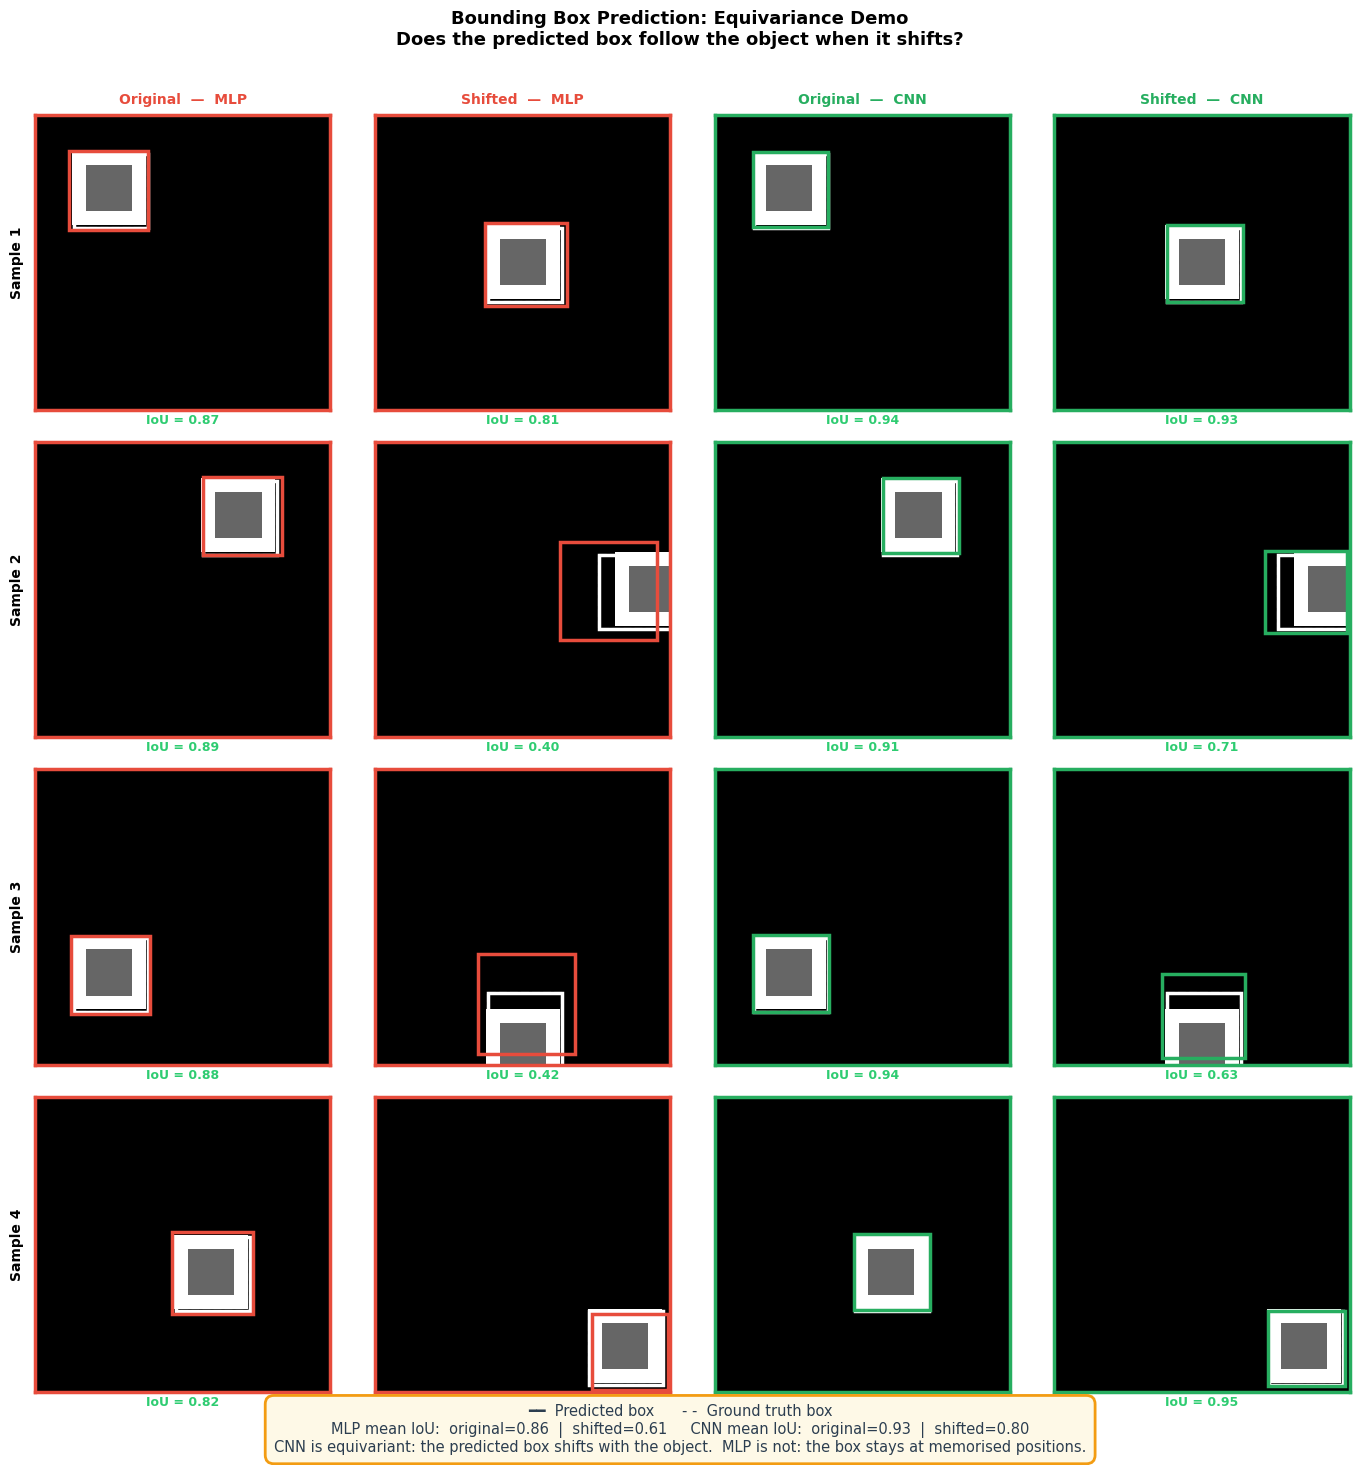

In [ ]:
# Reason3: Invariance
# ─────────────────────────────────────────────
# 1. Lets create synthetic dataset for object detection and show that how CNNs are translation equivariant.
#    Canvas: 64×64
#    Object: 16×16 white square with an inner darker ring

CANVAS   = 64
OBJ_SIZE = 16

import matplotlib.pyplot as plt
import matplotlib.patches as patches  # ← add this
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class ObjectDataset(Dataset):
    def __init__(self, n=3000):
        self.imgs, self.boxes = [], []
        max_pos = CANVAS - OBJ_SIZE
        for _ in range(n):
            canvas = np.zeros((1, CANVAS, CANVAS), dtype=np.float32)
            x = np.random.randint(0, max_pos)
            y = np.random.randint(0, max_pos)
            # outer bright ring
            canvas[0, y:y+OBJ_SIZE, x:x+OBJ_SIZE] = 1.0
            # inner darker fill — creates edge structure
            canvas[0, y+3:y+OBJ_SIZE-3, x+3:x+OBJ_SIZE-3] = 0.4
            # add tiny noise so MLP can't trivially memorize
            canvas += np.random.randn(1, CANVAS, CANVAS).astype(np.float32) * 0.05
            canvas = np.clip(canvas, 0, 1)
            self.imgs.append(canvas)
            # store normalised (x_center, y_center, w, h)
            self.boxes.append([
                (x + OBJ_SIZE / 2) / CANVAS,
                (y + OBJ_SIZE / 2) / CANVAS,
                OBJ_SIZE / CANVAS,
                OBJ_SIZE / CANVAS,
            ])
        self.imgs  = torch.tensor(np.array(self.imgs))
        self.boxes = torch.tensor(np.array(self.boxes), dtype=torch.float32)

    def __len__(self): return len(self.imgs)
    def __getitem__(self, i): return self.imgs[i], self.boxes[i]


# 2. MODELS
class MLPDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(CANVAS * CANVAS, 512), nn.ReLU(),
            nn.Linear(512, 256),             nn.ReLU(),
            nn.Linear(256, 4),               nn.Sigmoid(),
        )
    def forward(self, x): return self.net(x)


class CNNDetector(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                          # 64→32
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                          # 32→16
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),                          # 16→8
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256), nn.ReLU(),
            nn.Linear(256, 4),          nn.Sigmoid(),
        )
    def forward(self, x): return self.head(self.features(x))

# 3. TRAINING
def train(model, loader, epochs=25, lr=1e-3):
    opt      = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    model.train()
    for epoch in range(epochs):
        total = 0
        for imgs, boxes in loader:
            opt.zero_grad()
            loss = criterion(model(imgs), boxes)
            loss.backward()
            opt.step()
            total += loss.item()
        if (epoch + 1) % 5 == 0:
            print(f"  epoch {epoch+1:3d}/{epochs}  loss={total/len(loader):.5f}")
    return model


def iou(pred, gt, canvas=CANVAS):
    def to_xyxy(b):
        cx, cy, w, h = b
        return (cx - w/2) * canvas, (cy - h/2) * canvas, \
               (cx + w/2) * canvas, (cy + h/2) * canvas

    px1, py1, px2, py2 = to_xyxy(pred)
    gx1, gy1, gx2, gy2 = to_xyxy(gt)

    ix1, iy1 = max(px1, gx1), max(py1, gy1)
    ix2, iy2 = min(px2, gx2), min(py2, gy2)
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    union = (px2-px1)*(py2-py1) + (gx2-gx1)*(gy2-gy1) - inter
    return inter / union if union > 0 else 0.0


print("Building dataset...")
dataset    = ObjectDataset(n=3000)
loader     = DataLoader(dataset, batch_size=64, shuffle=True)

print("\nTraining MLP...")
mlp = MLPDetector()
mlp = train(mlp, loader, epochs=25)

print("\nTraining CNN...")
cnn = CNNDetector()
cnn = train(cnn, loader, epochs=25)


# 4. SHIFT HELPER
def shift_image(img, shift):
    """Shift image tensor (1,H,W) by `shift` pixels down-right."""
    shifted = torch.zeros_like(img)
    shifted[:, shift:, shift:] = img[:, :CANVAS-shift, :CANVAS-shift]
    return shifted

def predict_box(model, img_tensor):
    model.eval()
    with torch.no_grad():
        pred = model(img_tensor.unsqueeze(0)).squeeze().numpy()
    return pred

def box_to_rect(pred, color, label, canvas=CANVAS):
    """Convert normalised (cx,cy,w,h) → matplotlib Rectangle."""
    cx, cy, w, h = pred
    x1 = (cx - w/2) * canvas
    y1 = (cy - h/2) * canvas
    return patches.Rectangle(
        (x1, y1), w * canvas, h * canvas,
        linewidth=2.5, edgecolor=color, facecolor='none',
        label=label
    )


# 5. PICK 4 TEST SAMPLES & THEIR SHIFTED VERSIONS
# Use samples NOT in the training distribution
# by placing objects at fixed, well-separated positions

test_positions = [(8, 8), (36, 8), (8, 36), (30, 30)]
SHIFT = 16

test_imgs, test_boxes, shifted_imgs, shifted_boxes = [], [], [], []

for (x, y) in test_positions:
    canvas_np = np.zeros((1, CANVAS, CANVAS), dtype=np.float32)
    canvas_np[0, y:y+OBJ_SIZE, x:x+OBJ_SIZE] = 1.0
    canvas_np[0, y+3:y+OBJ_SIZE-3, x+3:x+OBJ_SIZE-3] = 0.4
    img = torch.tensor(canvas_np)

    sx, sy = min(x + SHIFT, CANVAS - OBJ_SIZE), min(y + SHIFT, CANVAS - OBJ_SIZE)
    test_imgs.append(img)
    test_boxes.append([(x + OBJ_SIZE/2)/CANVAS, (y + OBJ_SIZE/2)/CANVAS,
                        OBJ_SIZE/CANVAS, OBJ_SIZE/CANVAS])
    shifted_imgs.append(shift_image(img, SHIFT))
    shifted_boxes.append([(sx + OBJ_SIZE/2)/CANVAS, (sy + OBJ_SIZE/2)/CANVAS,
                           OBJ_SIZE/CANVAS, OBJ_SIZE/CANVAS])


# 6. COMPUTE IoU FOR ANNOTATION
mlp_iou_orig, mlp_iou_shift = [], []
cnn_iou_orig, cnn_iou_shift = [], []

for img, box, simg, sbox in zip(test_imgs, test_boxes, shifted_imgs, shifted_boxes):
    mlp_iou_orig.append(iou(predict_box(mlp, img),   box))
    mlp_iou_shift.append(iou(predict_box(mlp, simg), sbox))
    cnn_iou_orig.append(iou(predict_box(cnn, img),   box))
    cnn_iou_shift.append(iou(predict_box(cnn, simg), sbox))

print(f"\nMean IoU  |  original  |  shifted {SHIFT}px")
print(f"MLP       |  {np.mean(mlp_iou_orig):.3f}     |  {np.mean(mlp_iou_shift):.3f}")
print(f"CNN       |  {np.mean(cnn_iou_orig):.3f}     |  {np.mean(cnn_iou_shift):.3f}")



# 7. VISUALISE
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle(
    'Bounding Box Prediction: Equivariance Demo\n'
    'Does the predicted box follow the object when it shifts?',
    fontsize=13, fontweight='bold', y=1.01
)

col_titles = [
    'Original  —  MLP', 'Shifted  —  MLP',
    'Original  —  CNN', 'Shifted  —  CNN'
]
col_colors = ['#e74c3c', '#e74c3c', '#27ae60', '#27ae60']

for col, (title, color) in enumerate(zip(col_titles, col_colors)):
    axes[0, col].set_title(title, fontsize=10, fontweight='bold',
                            color=color, pad=8)

for row in range(4):
    orig_img  = test_imgs[row]
    shft_img  = shifted_imgs[row]
    gt_orig   = test_boxes[row]
    gt_shift  = shifted_boxes[row]

    mlp_pred_orig  = predict_box(mlp, orig_img)
    mlp_pred_shift = predict_box(mlp, shft_img)
    cnn_pred_orig  = predict_box(cnn, orig_img)
    cnn_pred_shift = predict_box(cnn, shft_img)

    configs = [
        (orig_img,  mlp_pred_orig,  gt_orig,  '#e74c3c', mlp_iou_orig[row]),
        (shft_img,  mlp_pred_shift, gt_shift, '#e74c3c', mlp_iou_shift[row]),
        (orig_img,  cnn_pred_orig,  gt_orig,  '#27ae60', cnn_iou_orig[row]),
        (shft_img,  cnn_pred_shift, gt_shift, '#27ae60', cnn_iou_shift[row]),
    ]

    for col, (img_t, pred, gt, model_color, score) in enumerate(configs):
        ax = axes[row, col]
        ax.imshow(img_t.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)

        # ground truth box (white dashed)
        ax.add_patch(box_to_rect(gt, 'white', 'GT'))
        gt_rect = patches.Rectangle(
            ((gt[0]-gt[2]/2)*CANVAS, (gt[1]-gt[3]/2)*CANVAS),
            gt[2]*CANVAS, gt[3]*CANVAS,
            linewidth=1.5, edgecolor='white',
            facecolor='none', linestyle='--'
        )
        ax.add_patch(gt_rect)

        # predicted box (colored)
        ax.add_patch(box_to_rect(pred, model_color, 'Pred'))

        ax.set_xticks([])
        ax.set_yticks([])

        # IoU label
        iou_color = '#2ecc71' if score > 0.4 else '#e74c3c'
        ax.set_xlabel(f'IoU = {score:.2f}', fontsize=9,
                      fontweight='bold', color=iou_color, labelpad=3)

        # border color = model color
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_edgecolor(model_color)
            spine.set_linewidth(2.5)

# Row labels
for row in range(4):
    axes[row, 0].set_ylabel(f'Sample {row+1}', fontsize=10,
                             fontweight='bold', labelpad=8)

# Legend

plt.tight_layout()
plt.savefig('bbox_equivariance_demo.png', dpi=150, bbox_inches='tight')
plt.show()

Found good cat at index 103: MLP=66%  CNN=73%


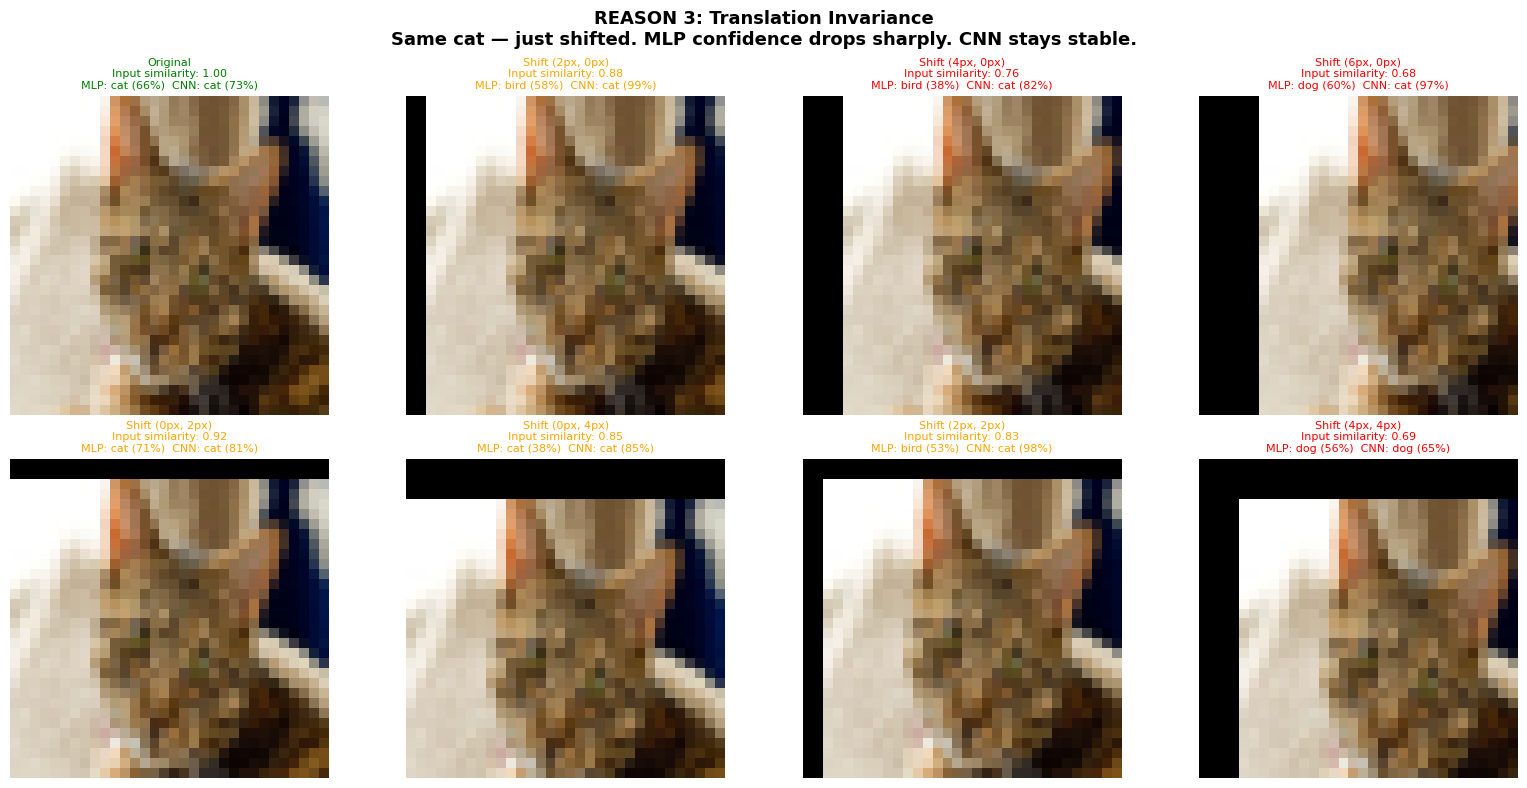

In [ ]:
# Reason3: Translation Invariance
class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Find a cat that BOTH models classify correctly with high confidence
cat_img = None
for i, (img_tensor, label) in enumerate(testset):
    if label != 3:
        continue
    img_unnorm = img_tensor * 0.5 + 0.5
    mlp_cls, mlp_conf = get_confidence(img_unnorm, model)
    cnn_cls, cnn_conf = get_confidence(img_unnorm, cnn_model)
    if mlp_cls == 3 and cnn_cls == 3 and mlp_conf > 60 and cnn_conf > 60:
        cat_img = img_unnorm
        print(f"Found good cat at index {i}: MLP={mlp_conf:.0f}%  CNN={cnn_conf:.0f}%")
        break

if cat_img is None:
    print("No high-confidence cat found — lowering thresholds...")
    for i, (img_tensor, label) in enumerate(testset):
        if label != 3:
            continue
        img_unnorm = img_tensor * 0.5 + 0.5
        mlp_cls, mlp_conf = get_confidence(img_unnorm, model)
        cnn_cls, cnn_conf = get_confidence(img_unnorm, cnn_model)
        if mlp_cls == 3 and cnn_cls == 3:
            cat_img = img_unnorm
            print(f"Found cat at index {i}: MLP={mlp_conf:.0f}%  CNN={cnn_conf:.0f}%")
            break

def shift_image(img, dx, dy):
    shifted = torch.zeros_like(img)
    x0, x1 = max(dx, 0), min(32 + dx, 32)
    y0, y1 = max(dy, 0), min(32 + dy, 32)
    sx0, sx1 = max(-dx, 0), min(32 - dx, 32)
    sy0, sy1 = max(-dy, 0), min(32 - dy, 32)
    shifted[:, y0:y1, x0:x1] = img[:, sy0:sy1, sx0:sx1]
    return shifted

def get_confidence(img_tensor, mdl):
    mdl.eval()
    x = (img_tensor - 0.5) / 0.5
    with torch.no_grad():
        logits = mdl(x.unsqueeze(0).to(device))
        probs  = torch.softmax(logits, dim=1)
    top_prob, top_cls = probs[0].max(0)
    return top_cls.item(), top_prob.item() * 100

# Small shifts for 32×32 images
shifts = [(0,0), (2,0), (4,0), (6,0), (0,2), (0,4), (2,2), (4,4)]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, (dx, dy) in zip(axes.flat, shifts):
    shifted = shift_image(cat_img, dx, dy)
    cos_sim = float(
        torch.nn.functional.cosine_similarity(
            cat_img.flatten().unsqueeze(0),
            shifted.flatten().unsqueeze(0)
        ).item()
    )
    mlp_cls, mlp_conf = get_confidence(shifted, model)
    cnn_cls, cnn_conf = get_confidence(shifted, cnn_model)

    ax.imshow(shifted.permute(1, 2, 0).clip(0, 1).numpy())
    ax.axis('off')

    is_original = (dx == 0 and dy == 0)
    title  = "Original\n" if is_original else f"Shift ({dx}px, {dy}px)\n"
    title += f"Input similarity: {cos_sim:.2f}\n"
    title += f"MLP: {class_names[mlp_cls]} ({mlp_conf:.0f}%)  "
    title += f"CNN: {class_names[cnn_cls]} ({cnn_conf:.0f}%)"
    color  = 'green' if is_original else ('orange' if cos_sim > 0.8 else 'red')
    ax.set_title(title, fontsize=8, color=color)

plt.suptitle(
    'REASON 3: Translation Invariance\n'
    'Same cat — just shifted. MLP confidence drops sharply. CNN stays stable.',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('reason3_translation_invariance.png', dpi=150, bbox_inches='tight')
plt.show()

Pretrained CNNs

In [ ]:
# We can use pretrained models for transfer learning with Pretrained ResNet-18
# Goal: freeze backbone - cache features - only train head
# To make it more efficient we will extract features once

import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# We need different DataLoaders for pretrained models because pretrained models expect this ---> 224×224
pretrain_transform_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=14),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])
pretrain_transform_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

pretrain_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=pretrain_transform_train)
pretrain_testset  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=pretrain_transform_test)

# Use smaller batch for extraction
extract_trainloader = torch.utils.data.DataLoader(
    pretrain_trainset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
extract_testloader  = torch.utils.data.DataLoader(
    pretrain_testset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# Load Pretrained ResNet-18 & strip the FC head
resnet_full = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
backbone = nn.Sequential(*list(resnet_full.children())[:-1])  # removes fc, keeps avgpool
backbone = backbone.to(device)
backbone.eval()

# Freeze everything: we only use this for feature extraction
for param in backbone.parameters():
    param.requires_grad = False

# Pre-compute features (runs ONCE, saves redundant fwd passes)
def extract_features(loader, model, desc=""):
    features_list, labels_list = [], []
    print(f"Extracting {desc} features...", end=" ", flush=True)
    t0 = time.time()
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            feats = model(inputs)          # (B, 512, 1, 1)
            features_list.append(feats.squeeze(-1).squeeze(-1).cpu())  # (B, 512)
            labels_list.append(labels)
    features = torch.cat(features_list)   # (N, 512)
    labels   = torch.cat(labels_list)     # (N,)
    print(f"done in {time.time()-t0:.1f}s  →  shape {tuple(features.shape)}")
    return features, labels

train_feats, train_labels = extract_features(extract_trainloader, backbone, "train")
test_feats,  test_labels  = extract_features(extract_testloader,  backbone, "test")

# Lightweight DataLoaders .
feat_trainset = torch.utils.data.TensorDataset(train_feats, train_labels)
feat_testset  = torch.utils.data.TensorDataset(test_feats,  test_labels)

feat_trainloader = torch.utils.data.DataLoader(
    feat_trainset, batch_size=256, shuffle=True)
feat_testloader  = torch.utils.data.DataLoader(
    feat_testset,  batch_size=512, shuffle=False)

# Define the head only: 512 → 10 (we have 10 classes for cifar10)
head = nn.Linear(512, 10).to(device)

total_params     = sum(p.numel() for p in head.parameters())

print(f"  ResNet-18  │  Linear Probing on CIFAR-10 (fast mode)")
print(f"  Trainable params   : {total_params:>10,} only the 10-class head")
print(f"  Backbone forward   :  extracted ONCE, not every epoch")


# Train the head on cached features
PRETRAIN_EPOCHS  = 20
resnet_optimizer = optim.Adam(head.parameters(), lr=1e-3, weight_decay=1e-4)
resnet_scheduler = optim.lr_scheduler.CosineAnnealingLR(resnet_optimizer, T_max=PRETRAIN_EPOCHS)
criterion        = nn.CrossEntropyLoss()

resnet_history = {'train_loss': [], 'test_acc': []}

print("Training: ONLY fc head on pre-computed 512-d features\n")

for epoch in range(PRETRAIN_EPOCHS):
    t0 = time.time()
    head.train()
    total_loss = 0
    for feats, labels in feat_trainloader:
        feats, labels = feats.to(device), labels.to(device)
        resnet_optimizer.zero_grad()
        loss = criterion(head(feats), labels)
        loss.backward()
        resnet_optimizer.step()
        total_loss += loss.item()

    head.eval()
    correct = total = 0
    with torch.no_grad():
        for feats, labels in feat_testloader:
            feats, labels = feats.to(device), labels.to(device)
            preds = head(feats).argmax(dim=1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)

    avg_loss = total_loss / len(feat_trainloader)
    acc      = 100. * correct / total
    resnet_scheduler.step()
    resnet_history['train_loss'].append(avg_loss)
    resnet_history['test_acc'].append(acc)
    print(f"Epoch [{epoch+1:2d}/{PRETRAIN_EPOCHS}]  Loss: {avg_loss:.4f}  "
          f"Test Acc: {acc:.1f}%  ({time.time()-t0:.1f}s)")

print(f"\n✓ ResNet-18 ({total_params:,} params)  : {max(resnet_history['test_acc']):.1f}%")

Using device: cuda

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 190MB/s]


Extracting train features... done in 116.0s  →  shape (50000, 512)
Extracting test features... done in 24.9s  →  shape (10000, 512)
  ResNet-18  │  Linear Probing on CIFAR-10 (fast mode)
  Trainable params   :      5,130 only the 10-class head
  Backbone forward   :  extracted ONCE, not every epoch
Training: ONLY fc head on pre-computed 512-d features

Epoch [ 1/20]  Loss: 0.8173  Test Acc: 82.0%  (0.6s)
Epoch [ 2/20]  Loss: 0.4654  Test Acc: 83.6%  (0.8s)
Epoch [ 3/20]  Loss: 0.4185  Test Acc: 84.3%  (0.6s)
Epoch [ 4/20]  Loss: 0.3947  Test Acc: 85.4%  (0.7s)
Epoch [ 5/20]  Loss: 0.3813  Test Acc: 85.2%  (0.9s)
Epoch [ 6/20]  Loss: 0.3723  Test Acc: 85.5%  (0.9s)
Epoch [ 7/20]  Loss: 0.3643  Test Acc: 85.7%  (0.7s)
Epoch [ 8/20]  Loss: 0.3587  Test Acc: 85.8%  (0.6s)
Epoch [ 9/20]  Loss: 0.3541  Test Acc: 85.5%  (1.2s)
Epoch [10/20]  Loss: 0.3498  Test Acc: 85.8%  (0.7s)
Epoch [11/20]  Loss: 0.3472  Test Acc: 86.0%  (1.0s)
Epoch [12/20]  Loss: 0.3438  Test Acc: 85.8%  (0.9s)
Epoch [13

In [ ]:
#  We do transfer Learning with pretrained vision transformer
#  Goal: Pre-extract [CLS] features ONCE → only train head
#  We apply the same trick as: backbone runs exactly once

!pip install timm --quiet

import timm
import time
import torch
import torch.nn as nn
import torch.optim as optim


# Build 224×224 ImageNet-normalised loaders
import torchvision
import torchvision.transforms as transforms

pretrain_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),   # ImageNet stats
])

pretrain_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True,  download=True, transform=pretrain_transform)
pretrain_testset  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=pretrain_transform)

pretrain_trainloader = torch.utils.data.DataLoader(
    pretrain_trainset, batch_size=256, shuffle=False, num_workers=2)
pretrain_testloader  = torch.utils.data.DataLoader(
    pretrain_testset,  batch_size=512, shuffle=False, num_workers=2)

print("Loaders ready — 224×224, ImageNet normalisation ✓")


# Load Pretrained ViT-Small
#  num_classes=0 → timm removes the head entirely and returns
#  the raw [CLS] token embedding instead of class logits.
#  This is the key difference vs ResNet where we sliced children().
vit_backbone = timm.create_model(
    'vit_small_patch16_224',
    pretrained=True,
    num_classes=0          # ← removes head, outputs [CLS] embedding
)
vit_backbone = vit_backbone.to(device)
vit_backbone.eval()

for param in vit_backbone.parameters():
    param.requires_grad = False

# What is the [CLS] embedding size?
#  ViT-Small hidden dim = 384  (if we have used Base=768, or Large=1024)
#  We extract this ONCE and cache it: same idea as ResNet's
dummy = torch.zeros(1, 3, 224, 224).to(device)
with torch.no_grad():
    cls_dim = vit_backbone(dummy).shape[-1]
print(f"ViT [CLS] embedding dimension: {cls_dim}")   # → 384

# Pre-compute [CLS] features (runs ONCE)
def extract_features(loader, model, desc=""):
    features_list, labels_list = [], []
    print(f"Extracting {desc} features...", end=" ", flush=True)
    t0 = time.time()
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            cls_tokens = model(inputs)          # (B, 384) — [CLS] token only
            features_list.append(cls_tokens.cpu())
            labels_list.append(labels)
    features = torch.cat(features_list)         # (N, 384)
    labels   = torch.cat(labels_list)           # (N,)
    print(f"done in {time.time()-t0:.1f}s  →  shape {tuple(features.shape)}")
    return features, labels

vit_train_feats, vit_train_labels = extract_features(pretrain_trainloader, vit_backbone, "ViT train")
vit_test_feats,  vit_test_labels  = extract_features(pretrain_testloader,  vit_backbone, "ViT test")

# Lightweight DataLoaders
vit_feat_trainset = torch.utils.data.TensorDataset(vit_train_feats, vit_train_labels)
vit_feat_testset  = torch.utils.data.TensorDataset(vit_test_feats,  vit_test_labels)

vit_feat_trainloader = torch.utils.data.DataLoader(
    vit_feat_trainset, batch_size=256, shuffle=True)
vit_feat_testloader  = torch.utils.data.DataLoader(
    vit_feat_testset,  batch_size=512, shuffle=False)

# Define head only (384 → 10)
vit_head = nn.Linear(cls_dim, 10).to(device)

vit_total     = sum(p.numel() for p in vit_backbone.parameters()) + sum(p.numel() for p in vit_head.parameters())
vit_trainable = sum(p.numel() for p in vit_head.parameters())


print(f"  ViT-Small Transfer Learning  │  CIFAR-10 (fast mode)")
print(f"  Total parameters   : {vit_total:>10,}")
print(f"  Trainable params   : {vit_trainable:>10,}  ← only {100*vit_trainable/vit_total:.2f}% updated!")
print(f"  [CLS] embed dim    : {cls_dim}  (vs ResNet's 512-d avgpool)")

# Train head on cached [CLS] features
VIT_EPOCHS    = 20
vit_optimizer = optim.Adam(vit_head.parameters(), lr=1e-3, weight_decay=1e-4)
vit_scheduler = optim.lr_scheduler.CosineAnnealingLR(vit_optimizer, T_max=VIT_EPOCHS)
criterion     = nn.CrossEntropyLoss()

vit_history = {'train_loss': [], 'test_acc': []}

print("Training: ONLY linear head on pre-computed 384-d [CLS] tokens\n")

for epoch in range(VIT_EPOCHS):
    t0 = time.time()
    vit_head.train()
    total_loss = 0
    for feats, labels in vit_feat_trainloader:
        feats, labels = feats.to(device), labels.to(device)
        vit_optimizer.zero_grad()
        loss = criterion(vit_head(feats), labels)
        loss.backward()
        vit_optimizer.step()
        total_loss += loss.item()

    vit_head.eval()
    correct = total = 0
    with torch.no_grad():
        for feats, labels in vit_feat_testloader:
            feats, labels = feats.to(device), labels.to(device)
            preds = vit_head(feats).argmax(dim=1)
            correct += preds.eq(labels).sum().item()
            total   += labels.size(0)

    avg_loss = total_loss / len(vit_feat_trainloader)
    acc      = 100. * correct / total
    vit_scheduler.step()
    vit_history['train_loss'].append(avg_loss)
    vit_history['test_acc'].append(acc)
    print(f"Epoch [{epoch+1:2d}/{VIT_EPOCHS}]  Loss: {avg_loss:.4f}  "
          f"Test Acc: {acc:.1f}%  ({time.time()-t0:.1f}s)")


print(f"  Final Accuracy Leaderboard")
print(f"  MLP      (scratch)              : {max(history['test_acc']):.1f}%")
print(f"  CNN      (scratch)              : {max(cnn_history['test_acc']):.1f}%")
print(f"  ResNet-18 (pretrained, head only): {max(resnet_history['test_acc']):.1f}%")
print(f"  ViT-Small (pretrained, head only): {max(vit_history['test_acc']):.1f}%")

print(f"\n→ MLP < CNN < Pretrained ResNet < Pretrained ViT ")
print(f"→ ViT trained {100*vit_trainable/vit_total:.2f}% of its weights and beat everything!")

Loaders ready — 224×224, ImageNet normalisation ✓


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

ViT [CLS] embedding dimension: 384
Extracting ViT train features... done in 197.2s  →  shape (50000, 384)
Extracting ViT test features... done in 40.7s  →  shape (10000, 384)
  ViT-Small Transfer Learning  │  CIFAR-10 (fast mode)
  Total parameters   : 21,669,514
  Trainable params   :      3,850  ← only 0.02% updated!
  [CLS] embed dim    : 384  (vs ResNet's 512-d avgpool)
Training: ONLY linear head on pre-computed 384-d [CLS] tokens

Epoch [ 1/20]  Loss: 0.4164  Test Acc: 91.9%  (0.6s)
Epoch [ 2/20]  Loss: 0.2049  Test Acc: 92.8%  (0.6s)
Epoch [ 3/20]  Loss: 0.1830  Test Acc: 92.9%  (0.6s)
Epoch [ 4/20]  Loss: 0.1716  Test Acc: 93.0%  (0.6s)
Epoch [ 5/20]  Loss: 0.1640  Test Acc: 93.2%  (0.8s)
Epoch [ 6/20]  Loss: 0.1587  Test Acc: 93.3%  (0.6s)
Epoch [ 7/20]  Loss: 0.1547  Test Acc: 93.4%  (0.6s)
Epoch [ 8/20]  Loss: 0.1512  Test Acc: 93.6%  (0.8s)
Epoch [ 9/20]  Loss: 0.1482  Test Acc: 93.3%  (0.8s)
Epoch [10/20]  Loss: 0.1458  Test Acc: 93.5%  (0.8s)
Epoch [11/20]  Loss: 0.1440  T